## Setup & Data Loading

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime, timedelta

# -- Global style --
sns.set_theme(style="white", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.family": "sans-serif",
})

# -- Palette --
BLUE = "#4361EE"
RED = "#E63946"
GREEN = "#06D6A0"
YELLOW = "#FFD166"
ORANGE = "#F77F00"
GREY = "#ADB5BD"
DARK = "#212529"
LIGHT_BG = "#F8F9FA"

con = duckdb.connect()
for table in ["users", "tracks", "artists", "sessions", "events"]:
    con.execute(f"""
        CREATE TABLE {table} AS
        SELECT * FROM read_csv_auto('../daily_mix_data/{table}.csv')
    """)
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table}: {n:,} rows")

print("\n All tables loaded.")

  users: 12,000 rows
  tracks: 2,441 rows
  artists: 500 rows
  sessions: 97,945 rows
  events: 747,848 rows

 All tables loaded.


## Dataset Overview
Quick sanity checks: user counts, variant split, signup window, platform and country distributions.

 total_users  control  treatment first_signup last_signup  countries  platforms
       12000     6065       5935   2025-01-06  2025-02-16          5          3


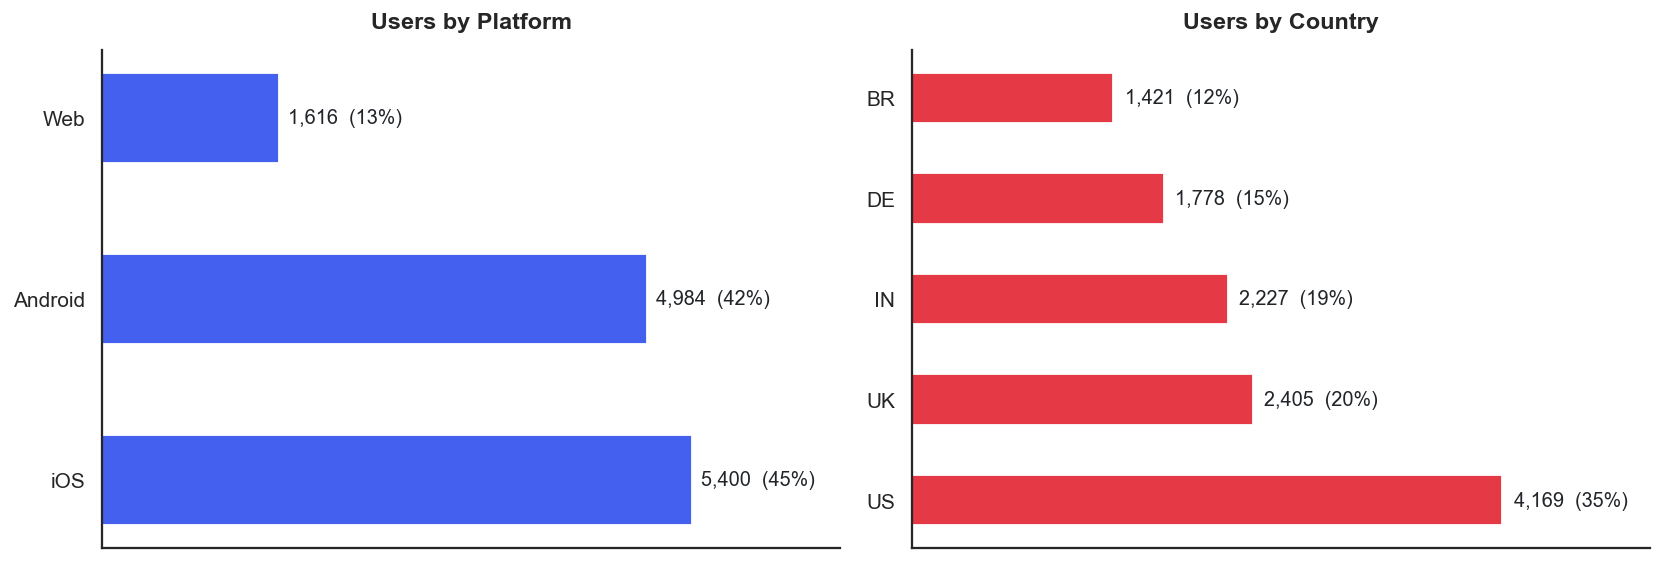

In [2]:
overview = con.execute("""
    SELECT
        COUNT(*) AS total_users,
        COUNT(CASE WHEN experiment_variant = 'control' THEN 1 END) AS control,
        COUNT(CASE WHEN experiment_variant = 'daily_mix' THEN 1 END) AS treatment,
        MIN(signup_date) AS first_signup,
        MAX(signup_date) AS last_signup,
        COUNT(DISTINCT country) AS countries,
        COUNT(DISTINCT platform) AS platforms
    FROM users
""").fetchdf()
print(overview.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

platform = con.execute("""
    SELECT platform, COUNT(*) AS n
    FROM users GROUP BY platform ORDER BY n DESC
""").fetchdf()
bars0 = axes[0].barh(platform["platform"], platform["n"], color=BLUE, height=0.5)
axes[0].set_title("Users by Platform", fontsize=13, fontweight="bold", pad=12)
axes[0].set_xlim(0, platform["n"].max() * 1.25)
axes[0].xaxis.set_visible(False)
for bar, v in zip(bars0, platform["n"]):
    axes[0].text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}  ({v/platform['n'].sum()*100:.0f}%)",
                 va="center", fontsize=11, color=DARK)

country = con.execute("""
    SELECT country, COUNT(*) AS n
    FROM users GROUP BY country ORDER BY n DESC
""").fetchdf()
bars1 = axes[1].barh(country["country"], country["n"], color=RED, height=0.5)
axes[1].set_title("Users by Country", fontsize=13, fontweight="bold", pad=12)
axes[1].set_xlim(0, country["n"].max() * 1.25)
axes[1].xaxis.set_visible(False)
for bar, v in zip(bars1, country["n"]):
    axes[1].text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
                 f"{v:,}  ({v/country['n'].sum()*100:.0f}%)",
                 va="center", fontsize=11, color=DARK)

plt.tight_layout()
plt.show()

## Activation Analysis: How Fast Do New Users Start Playing?
We define "activation" as playing a track within 2 minutes of first app open. This is a critical moment — friction here kills retention.

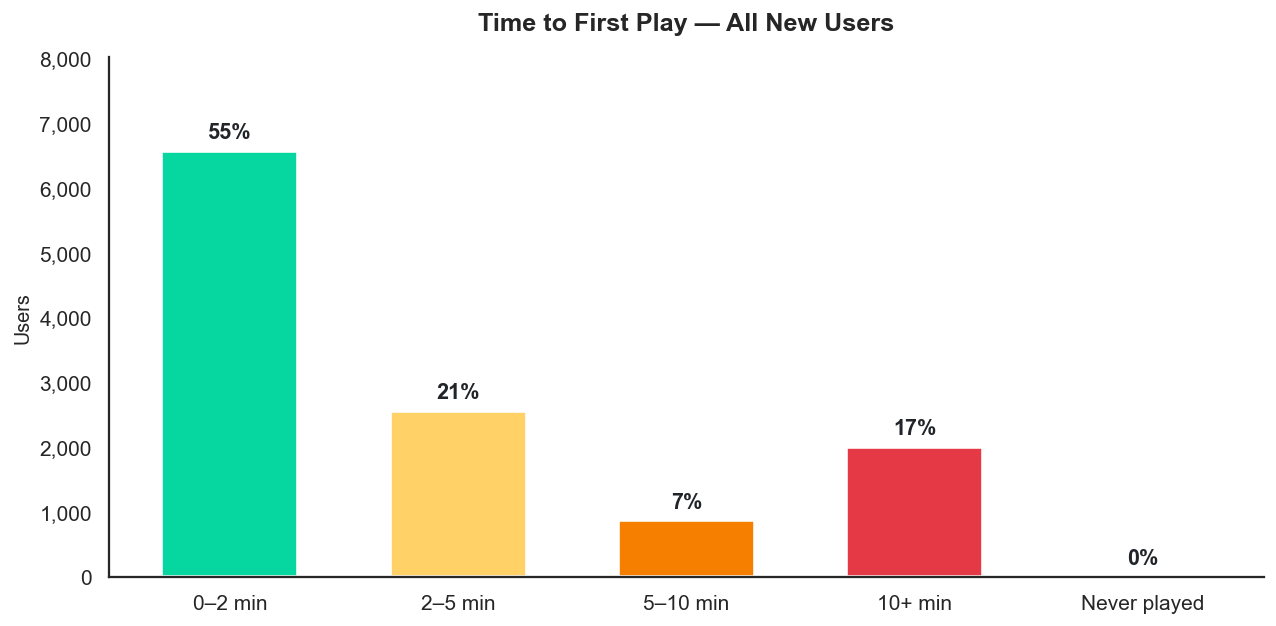

Activation rate (play within 2 min): 6,560 / 11,995 = 54.7%


In [3]:
activation = con.execute("""
    WITH first_open AS (
        SELECT user_id, MIN(event_time) AS first_open_time
        FROM events WHERE event_type = 'app_open'
        GROUP BY user_id
    ),
    first_play AS (
        SELECT user_id, MIN(event_time) AS first_play_time
        FROM events WHERE event_type IN ('play', 'daily_mix_play')
        GROUP BY user_id
    ),
    time_to_play AS (
        SELECT
            fo.user_id,
            EXTRACT(EPOCH FROM (fp.first_play_time - fo.first_open_time)) AS seconds_to_play
        FROM first_open fo
        LEFT JOIN first_play fp ON fo.user_id = fp.user_id
    )
    SELECT
        CASE
            WHEN seconds_to_play IS NULL THEN 'Never played'
            WHEN seconds_to_play <= 120  THEN '0–2 min'
            WHEN seconds_to_play <= 300  THEN '2–5 min'
            WHEN seconds_to_play <= 600  THEN '5–10 min'
            ELSE '10+ min'
        END AS activation_bucket,
        COUNT(*) AS users
    FROM time_to_play
    GROUP BY activation_bucket
""").fetchdf()

bucket_order = ["0–2 min", "2–5 min", "5–10 min", "10+ min", "Never played"]
activation["activation_bucket"] = pd.Categorical(
    activation["activation_bucket"], categories=bucket_order, ordered=True
)
activation = activation.sort_values("activation_bucket")
total = activation["users"].sum()

palette = [GREEN, YELLOW, ORANGE, RED, GREY]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(activation["activation_bucket"], activation["users"],
              color=palette, width=0.6, edgecolor="white", linewidth=2)

ax.set_title("Time to First Play — All New Users", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Users", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(0, activation["users"].max() * 1.22)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

for bar, val in zip(bars, activation["users"]):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + activation["users"].max() * 0.02,
            f"{pct:.0f}%", ha="center", va="bottom", fontsize=12, fontweight="bold", color=DARK)

plt.tight_layout()
plt.show()

fast = activation.loc[activation["activation_bucket"] == "0–2 min", "users"].values[0]
print(f"Activation rate (play within 2 min): {fast:,} / {total:,} = {fast/total*100:.1f}%")

## Retention Curve (D0–D30)
Classic N-day retention: % of users active on exactly day N after signup. This is the headline metric.
> **Note:** This curve includes both control and treatment users as a baseline overview. Variant-level retention is analysed in the experiment notebook.

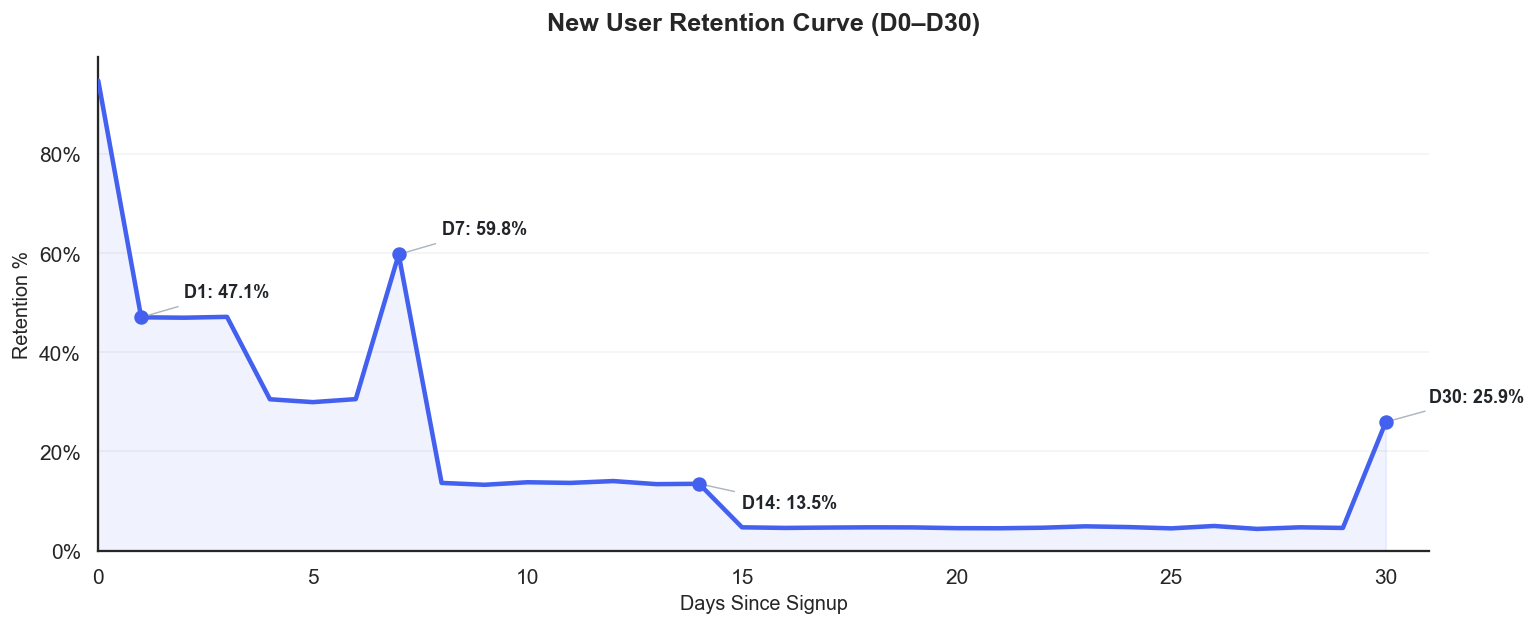

In [4]:
retention_curve = con.execute("""
    WITH active_days AS (
        SELECT
            u.user_id,
            CAST(e.event_time AS DATE) - CAST(u.signup_date AS DATE) AS day_n
        FROM events e
        JOIN users u ON e.user_id = u.user_id
        WHERE e.event_type IN ('play', 'app_open', 'daily_mix_play')
          AND CAST(e.event_time AS DATE) - CAST(u.signup_date AS DATE) BETWEEN 0 AND 30
    ),
    cohort AS (
        SELECT COUNT(DISTINCT user_id) AS total FROM users
    )
    SELECT
        ad.day_n,
        COUNT(DISTINCT ad.user_id) AS active,
        cohort.total AS cohort_size,
        ROUND(100.0 * COUNT(DISTINCT ad.user_id) / cohort.total, 2) AS retention_pct
    FROM active_days ad
    CROSS JOIN cohort
    GROUP BY ad.day_n, cohort.total
    ORDER BY ad.day_n
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(retention_curve["day_n"], retention_curve["retention_pct"],
        color=BLUE, linewidth=2.5, zorder=3)
ax.fill_between(retention_curve["day_n"], retention_curve["retention_pct"],
                alpha=0.08, color=BLUE)

ax.axhline(y=0, color="#DEE2E6", linewidth=0.8)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.15, color="#ADB5BD")

for day in [1, 7, 14, 30]:
    row = retention_curve[retention_curve["day_n"] == day]
    if len(row) > 0:
        val = row["retention_pct"].values[0]
        ax.plot(day, val, "o", color=BLUE, markersize=7, zorder=4)
        offset_y = 4 if day != 14 else -5
        ax.annotate(f"D{day}: {val:.1f}%",
                    xy=(day, val), xytext=(day + 1, val + offset_y),
                    fontsize=10, fontweight="bold", color=DARK,
                    arrowprops=dict(arrowstyle="-", color="#ADB5BD", lw=0.8))

ax.set_title("New User Retention Curve (D0–D30)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Days Since Signup", fontsize=11)
ax.set_ylabel("Retention %", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 31)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Retention Breakdown: Platform & Country
Are there segments that are dragging down the average?

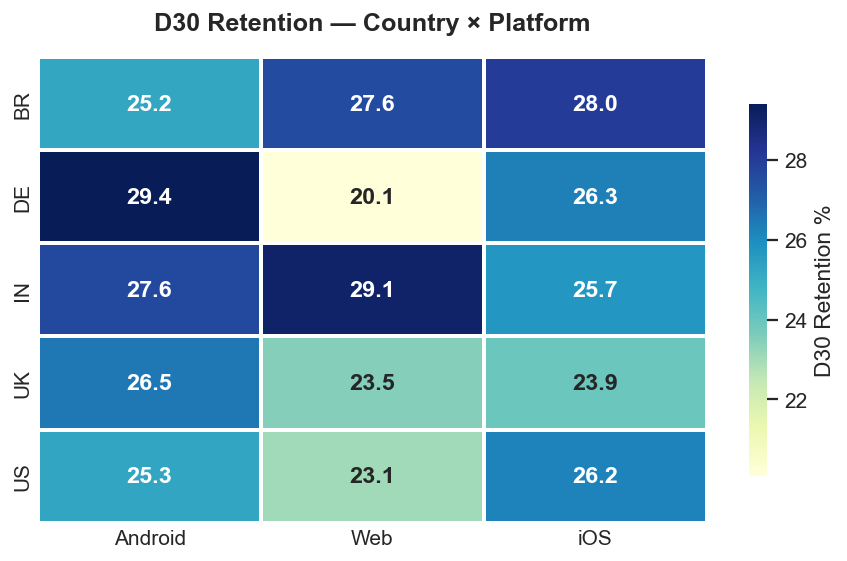

In [5]:
retention_segments = con.execute("""
    WITH d7 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 7
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    ),
    d30 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 30
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        u.platform,
        u.country,
        COUNT(DISTINCT u.user_id) AS cohort,
        ROUND(100.0 * COUNT(DISTINCT d7.user_id) / COUNT(DISTINCT u.user_id), 2) AS d7_pct,
        ROUND(100.0 * COUNT(DISTINCT d30.user_id) / COUNT(DISTINCT u.user_id), 2) AS d30_pct
    FROM users u
    LEFT JOIN d7 ON u.user_id = d7.user_id
    LEFT JOIN d30 ON u.user_id = d30.user_id
    GROUP BY u.platform, u.country
    ORDER BY u.platform, d30_pct DESC
""").fetchdf()

pivot = retention_segments.pivot_table(
    index="country", columns="platform", values="d30_pct", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu",
            linewidths=2, linecolor="white", ax=ax,
            annot_kws={"size": 13, "fontweight": "bold"},
            cbar_kws={"label": "D30 Retention %", "shrink": 0.8})
ax.set_title("D30 Retention — Country × Platform", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="both", length=0)

plt.tight_layout()
plt.show()

## First-Week Engagement
How much are new users listening in their first 7 days? Engagement is typically highly skewed — most users are light, a few are heavy.

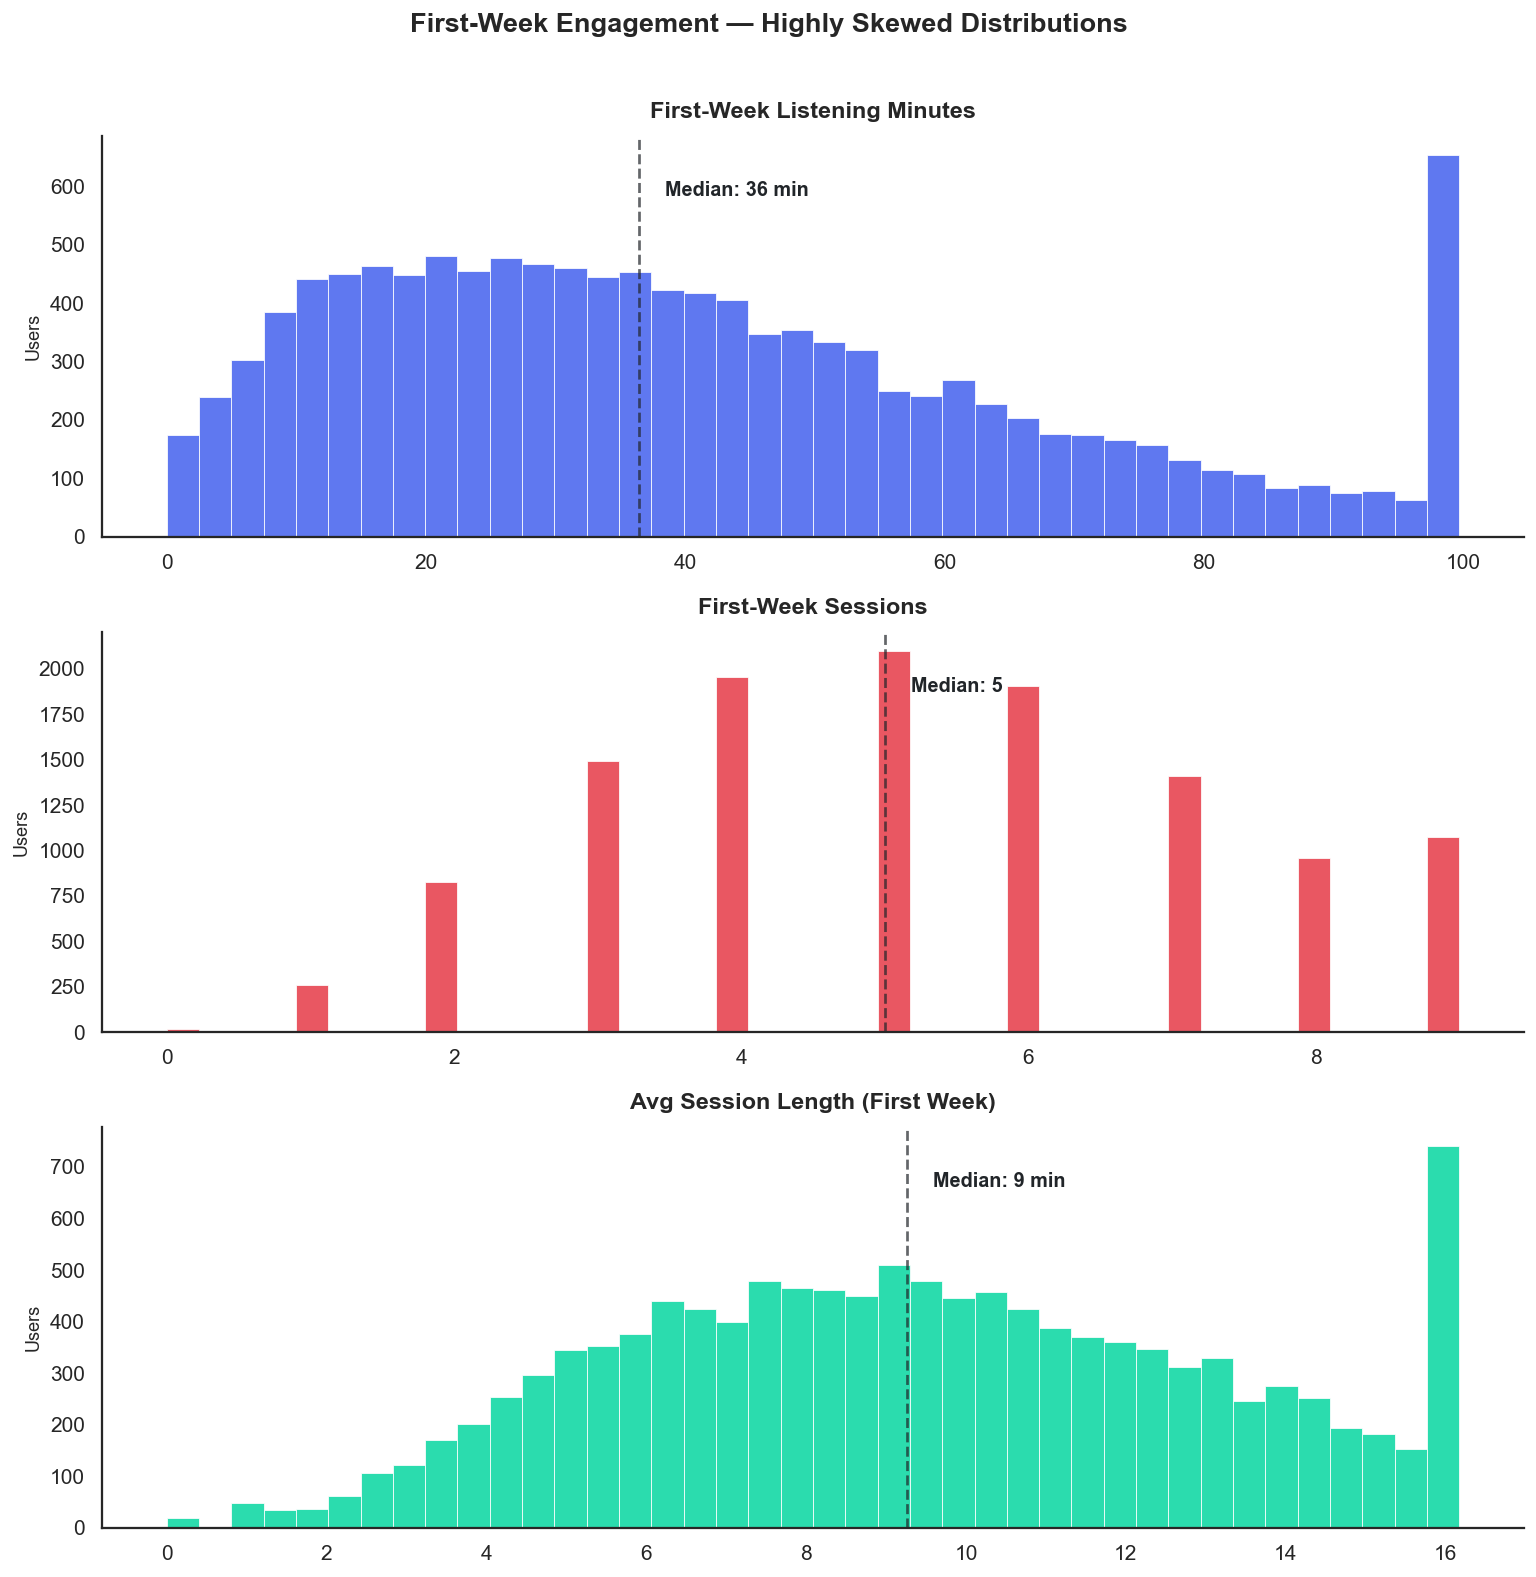

Listening: mean=42 min, median=36 min, p95=100 min
Sessions: mean=5.3, median=5
Session length: mean=9.5 min, median=9.3 min


In [6]:
engagement = con.execute("""
    SELECT
        u.user_id,
        COALESCE(SUM(s.total_play_ms) / 60000.0, 0) AS listening_min,
        COALESCE(COUNT(DISTINCT s.session_id), 0) AS sessions,
        COALESCE(AVG(EXTRACT(EPOCH FROM
            (CAST(s.session_end AS TIMESTAMP) - CAST(s.session_start AS TIMESTAMP))
        ) / 60.0), 0) AS avg_session_min
    FROM users u
    LEFT JOIN sessions s
        ON u.user_id = s.user_id
        AND CAST(s.session_start AS DATE) < CAST(u.signup_date AS DATE) + 8
        AND CAST(s.session_start AS DATE) >= CAST(u.signup_date AS DATE)
    GROUP BY u.user_id
""").fetchdf()

configs = [
    ("listening_min", "First-Week Listening Minutes", BLUE, "min"),
    ("sessions", "First-Week Sessions", RED, ""),
    ("avg_session_min", "Avg Session Length (First Week)", GREEN, "min"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for ax, (col, title, color, unit) in zip(axes, configs):
    data = engagement[col]
    cap = data.quantile(0.95)
    clipped = data.clip(upper=cap)

    ax.hist(clipped, bins=40, color=color, alpha=0.85, edgecolor="white", linewidth=0.5)
    med = data.median()
    ax.axvline(med, color=DARK, ls="--", lw=1.5, alpha=0.7)
    ax.text(med + cap * 0.02, ax.get_ylim()[1] * 0.85,
            f"Median: {med:.0f} {unit}", fontsize=11, fontweight="bold", color=DARK)

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("Users", fontsize=10)

plt.suptitle("First-Week Engagement — Highly Skewed Distributions",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"Listening: mean={engagement['listening_min'].mean():.0f} min, "
      f"median={engagement['listening_min'].median():.0f} min, "
      f"p95={engagement['listening_min'].quantile(0.95):.0f} min")
print(f"Sessions: mean={engagement['sessions'].mean():.1f}, "
      f"median={engagement['sessions'].median():.0f}")
print(f"Session length: mean={engagement['avg_session_min'].mean():.1f} min, "
      f"median={engagement['avg_session_min'].median():.1f} min")

## Insight: Speed to First Play Predicts D7 Retention
**Hypothesis:** Users who start playing within 2 minutes of opening the app retain significantly better — suggesting friction in the "first play" moment is a key driver of early churn.

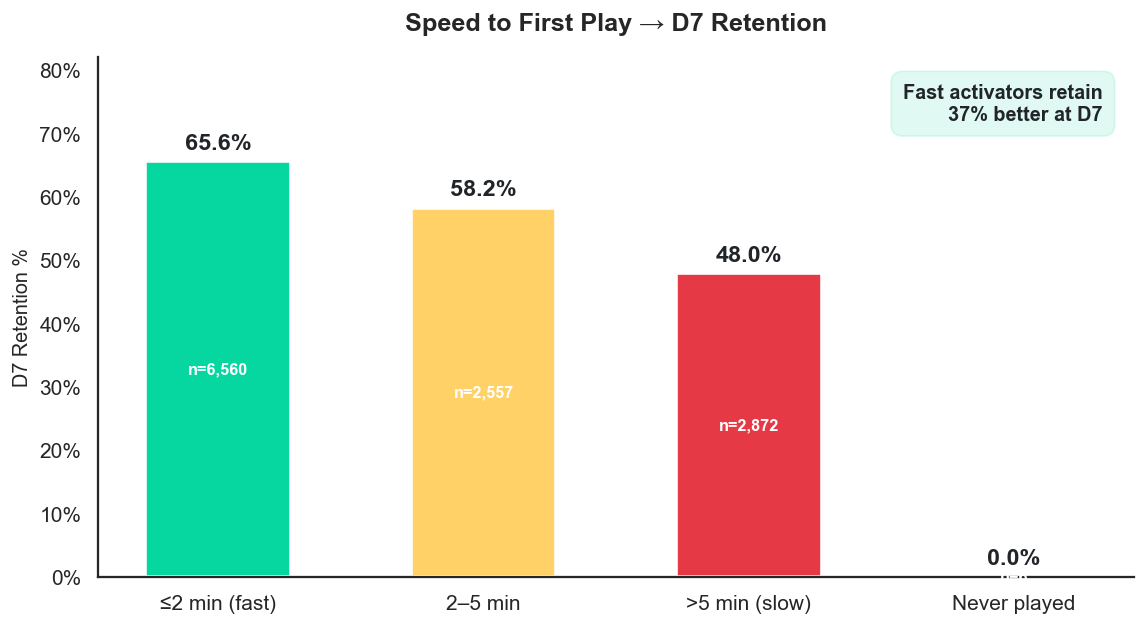

In [7]:
insight1 = con.execute("""
    WITH first_open AS (
        SELECT user_id, MIN(event_time) AS t
        FROM events WHERE event_type = 'app_open' GROUP BY user_id
    ),
    first_play AS (
        SELECT user_id, MIN(event_time) AS t
        FROM events WHERE event_type IN ('play', 'daily_mix_play') GROUP BY user_id
    ),
    classified AS (
        SELECT
            fo.user_id,
            CASE
                WHEN fp.t IS NULL THEN 'Never played'
                WHEN EXTRACT(EPOCH FROM (fp.t - fo.t)) <= 120 THEN '≤2 min (fast)'
                WHEN EXTRACT(EPOCH FROM (fp.t - fo.t)) <= 300 THEN '2–5 min'
                ELSE '>5 min (slow)'
            END AS speed
        FROM first_open fo
        LEFT JOIN first_play fp ON fo.user_id = fp.user_id
    ),
    d7 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 7
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        c.speed,
        COUNT(DISTINCT c.user_id) AS users,
        COUNT(DISTINCT d7.user_id) AS retained_d7,
        ROUND(100.0 * COUNT(DISTINCT d7.user_id) / COUNT(DISTINCT c.user_id), 2) AS d7_pct
    FROM classified c
    LEFT JOIN d7 ON c.user_id = d7.user_id
    GROUP BY c.speed
""").fetchdf()

speed_order = ["≤2 min (fast)", "2–5 min", ">5 min (slow)", "Never played"]
insight1["speed"] = pd.Categorical(insight1["speed"], categories=speed_order, ordered=True)
insight1 = insight1.sort_values("speed")
insight1 = insight1[insight1["users"] > 0]  # drop empty buckets

palette = [GREEN, YELLOW, RED, GREY][:len(insight1)]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(insight1["speed"], insight1["d7_pct"], color=palette,
              width=0.55, edgecolor="white", linewidth=2)

ax.set_ylim(0, insight1["d7_pct"].max() * 1.25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Speed to First Play → D7 Retention", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("D7 Retention %", fontsize=11)
ax.set_xlabel("")

for bar, val, n in zip(bars, insight1["d7_pct"], insight1["users"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + insight1["d7_pct"].max() * 0.02,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=13, fontweight="bold", color=DARK)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5,
            f"n={n:,}", ha="center", va="center", fontsize=9, color="white", fontweight="bold")

# Callout — compare fastest vs slowest non-empty bucket
played = insight1[insight1["speed"] != "Never played"]
if len(played) >= 2:
    fast_pct = played["d7_pct"].iloc[0]
    slow_pct = played["d7_pct"].iloc[-1]
    if slow_pct > 0:
        lift = (fast_pct - slow_pct) / slow_pct * 100
        ax.text(0.97, 0.95, f"Fast activators retain\n{lift:.0f}% better at D7",
                transform=ax.transAxes, fontsize=11, fontweight="bold", color=DARK,
                va="top", ha="right",
                bbox=dict(boxstyle="round,pad=0.6", facecolor=GREEN, alpha=0.12, edgecolor=GREEN))

plt.tight_layout()
plt.show()

## Insight: Deep Session → D30 Retention
**Hypothesis:** A Single Deep Session Changes Everything. Users who experience at least one 15+ minute uninterrupted listening session within their first 72 hours have dramatically higher D30 retention. This suggests the "aha moment" for music streaming is a lean-back listening experience.

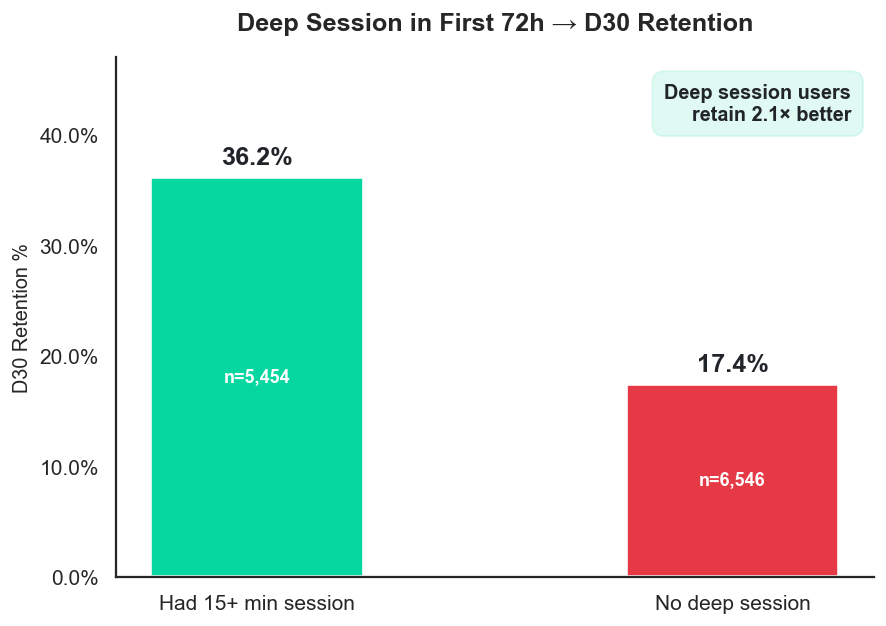

In [8]:
insight2 = con.execute("""
    WITH deep_flag AS (
        SELECT
            u.user_id,
            MAX(CASE
                WHEN EXTRACT(EPOCH FROM (
                    CAST(s.session_end AS TIMESTAMP) - CAST(s.session_start AS TIMESTAMP)
                )) / 60.0 >= 15
                AND CAST(s.session_start AS DATE) >= CAST(u.signup_date AS DATE)
                AND CAST(s.session_start AS DATE) < CAST(u.signup_date AS DATE) + 3
                THEN 1 ELSE 0
            END) AS had_deep
        FROM users u
        LEFT JOIN sessions s ON u.user_id = s.user_id
        GROUP BY u.user_id
    ),
    d30 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 30
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        CASE WHEN df.had_deep = 1
             THEN 'Had 15+ min session'
             ELSE 'No deep session'
        END AS segment,
        COUNT(DISTINCT df.user_id) AS users,
        COUNT(DISTINCT d30.user_id) AS retained,
        ROUND(100.0 * COUNT(DISTINCT d30.user_id) / COUNT(DISTINCT df.user_id), 2) AS d30_pct
    FROM deep_flag df
    LEFT JOIN d30 ON df.user_id = d30.user_id
    GROUP BY segment
""").fetchdf()

# Sort so deep session is on the left
insight2 = insight2.sort_values("d30_pct", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = [GREEN if "15+" in s else RED for s in insight2["segment"]]
bars = ax.bar(insight2["segment"], insight2["d30_pct"], color=colors,
              width=0.45, edgecolor="white", linewidth=2)

ax.set_ylim(0, insight2["d30_pct"].max() * 1.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Deep Session in First 72h → D30 Retention", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("D30 Retention %", fontsize=11)
ax.set_xlabel("")

for bar, val, n in zip(bars, insight2["d30_pct"], insight2["users"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + insight2["d30_pct"].max() * 0.02,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 0.5,
            f"n={n:,}", ha="center", va="center", fontsize=10, color="white", fontweight="bold")

# Callout
deep_val = insight2.loc[insight2["segment"].str.contains("15"), "d30_pct"].values[0]
no_deep = insight2.loc[~insight2["segment"].str.contains("15"), "d30_pct"].values[0]
if no_deep > 0:
    ratio = deep_val / no_deep
    ax.text(0.97, 0.95, f"Deep session users\nretain {ratio:.1f}× better",
            transform=ax.transAxes, fontsize=11, fontweight="bold", color=DARK,
            va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.6", facecolor=GREEN, alpha=0.12, edgecolor=GREEN))

plt.tight_layout()
plt.show()

## Insight: Artist Discovery → D30 Retention (Controlled) Discovery Drives Retention
**Hypothesis:** Users who discover 3+ new artists in their first week retain better — and this effect holds even when we control for total listening time. This means discovery itself matters, not just "being a heavy user."

**Method:** We bin users into listening-time terciles (low/med/high), then compare discovery vs retention *within* each bin. This is a stratified analysis — a simplified causal control.

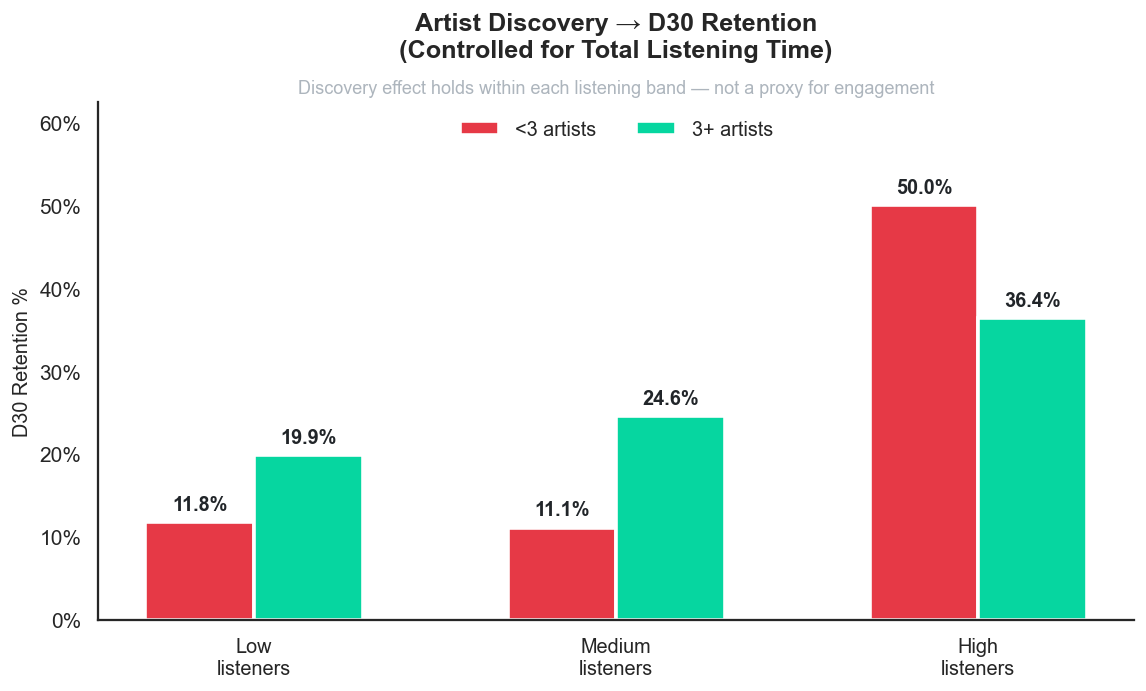

In [9]:
insight3 = con.execute("""
    WITH first_week_plays AS (
        SELECT e.user_id, t.artist_id
        FROM events e
        JOIN users u ON e.user_id = u.user_id
        JOIN tracks t ON e.track_id = t.track_id
        WHERE e.event_type IN ('play', 'daily_mix_play')
          AND CAST(e.event_time AS DATE) < CAST(u.signup_date AS DATE) + 8
    ),
    discovery AS (
        SELECT user_id, COUNT(DISTINCT artist_id) AS unique_artists
        FROM first_week_plays GROUP BY user_id
    ),
    listening AS (
        SELECT s.user_id, SUM(s.total_play_ms) / 60000.0 AS total_min
        FROM sessions s JOIN users u ON s.user_id = u.user_id
        WHERE CAST(s.session_start AS DATE) < CAST(u.signup_date AS DATE) + 8
        GROUP BY s.user_id
    ),
    segments AS (
        SELECT
            d.user_id,
            d.unique_artists,
            CASE WHEN d.unique_artists >= 3 THEN '3+ artists' ELSE '<3 artists' END AS disc_group,
            NTILE(3) OVER (ORDER BY l.total_min) AS listening_tercile
        FROM discovery d
        JOIN listening l ON d.user_id = l.user_id
    ),
    d30 AS (
        SELECT DISTINCT e.user_id
        FROM events e JOIN users u ON e.user_id = u.user_id
        WHERE CAST(e.event_time AS DATE) = CAST(u.signup_date AS DATE) + 30
          AND e.event_type IN ('play', 'app_open', 'daily_mix_play')
    )
    SELECT
        CASE s.listening_tercile
            WHEN 1 THEN 'Low'
            WHEN 2 THEN 'Medium'
            WHEN 3 THEN 'High'
        END AS tercile,
        s.disc_group,
        COUNT(DISTINCT s.user_id) AS users,
        COUNT(DISTINCT d30.user_id) AS retained,
        ROUND(100.0 * COUNT(DISTINCT d30.user_id) / COUNT(DISTINCT s.user_id), 2) AS d30_pct
    FROM segments s
    LEFT JOIN d30 ON s.user_id = d30.user_id
    GROUP BY s.listening_tercile, s.disc_group
    ORDER BY s.listening_tercile, s.disc_group
""").fetchdf()

# Note: inner join on discovery + listening excludes users with zero first-week plays. Intentional — we're analysing discovery
# behaviour among users who engaged at least minimally.

fig, ax = plt.subplots(figsize=(9, 5.5))

terciles = ["Low", "Medium", "High"]
x = np.arange(len(terciles))
width = 0.3

low_disc = insight3[insight3["disc_group"] == "<3 artists"].set_index("tercile").reindex(terciles)
high_disc = insight3[insight3["disc_group"] == "3+ artists"].set_index("tercile").reindex(terciles)

bars1 = ax.bar(x - width/2, low_disc["d30_pct"], width, label="<3 artists",
               color=RED, edgecolor="white", linewidth=2)
bars2 = ax.bar(x + width/2, high_disc["d30_pct"], width, label="3+ artists",
               color=GREEN, edgecolor="white", linewidth=2)

max_val = insight3["d30_pct"].max()
ax.set_ylim(0, max_val * 1.25)

for bars_group in [bars1, bars2]:
    for bar, val in zip(bars_group, [row for _, row in (low_disc if bars_group is bars1 else high_disc).iterrows()]):
        if pd.notna(val["d30_pct"]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.02,
                    f'{val["d30_pct"]:.1f}%', ha="center", va="bottom",
                    fontsize=11, fontweight="bold", color=DARK)

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\nlisteners" for t in terciles], fontsize=11)
ax.set_title("Artist Discovery → D30 Retention\n(Controlled for Total Listening Time)",
             fontsize=14, fontweight="bold", pad=25)
ax.text(0.5, 1.01, "Discovery effect holds within each listening band — not a proxy for engagement",
        transform=ax.transAxes, fontsize=10, color=GREY,
        ha="center", va="bottom")
ax.set_ylabel("D30 Retention %", fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=11, frameon=False, loc="upper center", ncol=2)

plt.tight_layout()
plt.show()

## Listening Source Mix
Where does listening time come from? If most plays come from Search rather than Home/playlists, it confirms the problem: users are *working* to find music instead of leaning back.

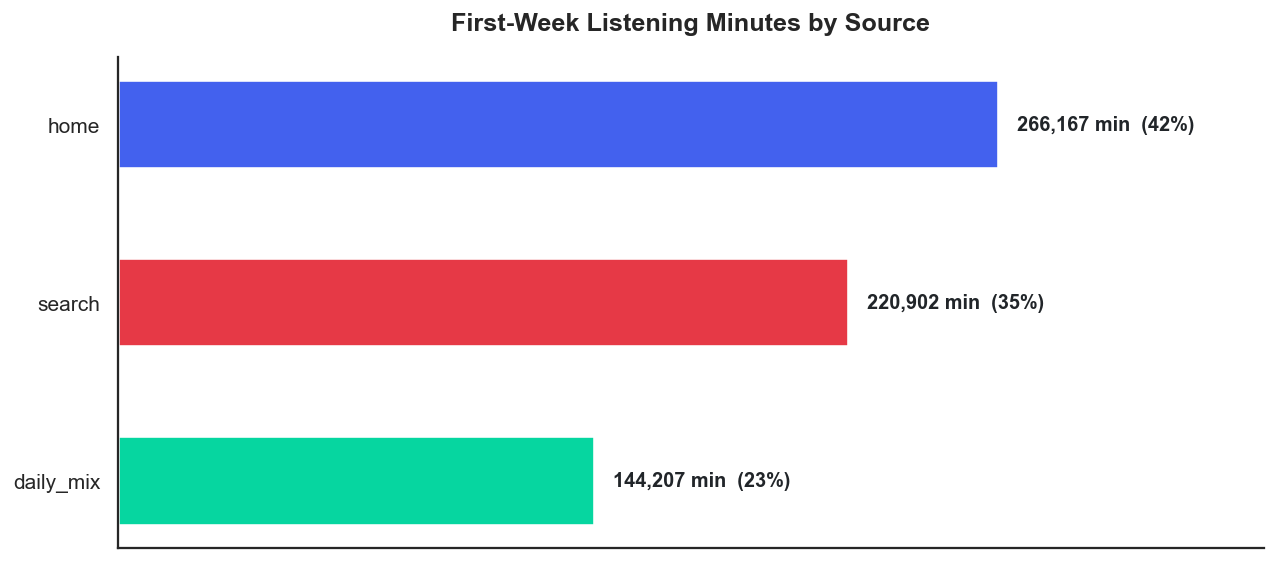

In [10]:
source_mix = con.execute("""
    SELECT
        COALESCE(e.source, 'unknown') AS source,
        COUNT(*) AS plays,
        COUNT(DISTINCT e.user_id) AS users,
        ROUND(SUM(t.duration_ms) / 60000.0, 0) AS total_min
    FROM events e
    JOIN users u ON e.user_id = u.user_id
    JOIN tracks t ON e.track_id = t.track_id
    WHERE e.event_type IN ('play', 'daily_mix_play')
      AND CAST(e.event_time AS DATE) < CAST(u.signup_date AS DATE) + 8
    GROUP BY source
    ORDER BY total_min DESC
""").fetchdf()

source_mix["pct"] = source_mix["total_min"] / source_mix["total_min"].sum() * 100

palette = [BLUE, RED, GREEN, YELLOW, ORANGE, GREY][:len(source_mix)]

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.barh(source_mix["source"], source_mix["total_min"], color=palette, height=0.5,
               edgecolor="white", linewidth=2)

ax.set_title("First-Week Listening Minutes by Source", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.xaxis.set_visible(False)
ax.set_xlim(0, source_mix["total_min"].max() * 1.3)
ax.invert_yaxis()

for bar, mins, pct in zip(bars, source_mix["total_min"], source_mix["pct"]):
    ax.text(bar.get_width() + source_mix["total_min"].max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{mins:,.0f} min  ({pct:.0f}%)",
            va="center", fontsize=11, fontweight="bold", color=DARK)

plt.tight_layout()
plt.show()

## Summary of Baseline Findings

### The Problem
- D30 retention sits at ~23% — only about 1 in 4 new users comes back after a month.
- First-week engagement is highly skewed: a small minority of power users drives the averages up, masking that most new users barely engage.
- A significant share of first-week listening comes from Search, meaning users are actively *working* to find music rather than leaning back.

### Three Behavioural Insights

| # | Insight | Effect | Implication |
|---|---------|--------|-------------|
| 1 | Fast first play (≤2 min) | ~37% higher D7 retention | Reduce friction to first play |
| 2 | Deep session (15+ min) in 72h | ~2.1× higher D30 retention | Enable lean-back listening |
| 3 | 3+ artists discovered in week 1 | ~1.5× D30 retention (controlled) | Preserve discovery/diversity |

### What This Motivates
A feature that:
- Gets users playing **immediately** (fast activation)
- Encourages **long, uninterrupted sessions** (deep listening)
- Introduces **new artists** (discovery and diversity)

→ **Daily Mix**: a personalised lean-back playlist pinned on Home.

### Caveats
- This is observational data. The insights show strong *correlations*, and the stratified analysis (Insight 3) controls for engagement level, but true causal evidence requires an experiment — which is the next notebook.
- Retention is measured as "active on exactly day N" (classic retention), which is standard but noisy for any single day.